# 05 — Running Experiments

The **Experiment** class automates cross-validated evaluation of multiple
fairness methods across datasets, classifiers, and metrics. It returns a
results DataFrame that plugs straight into ComparisonReport.

In [6]:
from sklearn.linear_model import LogisticRegression
from skfair.experimentation import Experiment

## Configure and run

Specify datasets, methods, classifiers, metrics, and the number of CV folds.
Method and dataset names come from the built-in registries.

In [7]:
exp = Experiment(
    datasets=["ricci"],
    methods=["Baseline", "FairSmote", "Massaging"],
    classifiers={"LogReg": LogisticRegression(solver="liblinear", max_iter=1000, random_state=42)},
    metrics=["accuracy", "spd"],
    n_splits=2,
    random_state=42,
)

results = exp.run(verbose=True)
results


Dataset: Ricci
  Baseline                       | LogReg  acc=0.703  spd=-0.668
  FairSmote                      | LogReg  acc=0.788  spd=-0.065
  Massaging                      | LogReg  acc=0.619  spd=0.066


,dataset,method,classifier,accuracy_mean,accuracy_std,spd_mean,spd_std
0,Ricci,Baseline,LogReg,0.703390,0.059322,-0.667959,0.210487
1,Ricci,FairSmote,LogReg,0.788136,0.042373,-0.064761,0.152480
2,Ricci,Massaging,LogReg,0.618644,0.008475,0.066118,0.184509


## Save results

`save()` writes the results DataFrame and/or the full Experiment object.
Pass `results=True` for CSV, `object=True` for a pickle. The path is a
base name — extensions are added automatically.

In [8]:
import os
os.makedirs("outputs", exist_ok=True)

exp.save("outputs/results", results=True)
print("Saved to outputs/results.csv")

Saved to outputs/results.csv


## Convert to ComparisonReport

The `to_report()` method wraps the results in a ComparisonReport so you can
immediately produce plots and summary tables (see notebook 04).

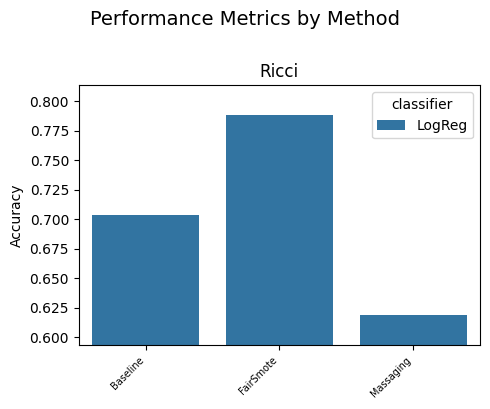

In [9]:
report = exp.to_report()
report.plot_performance();

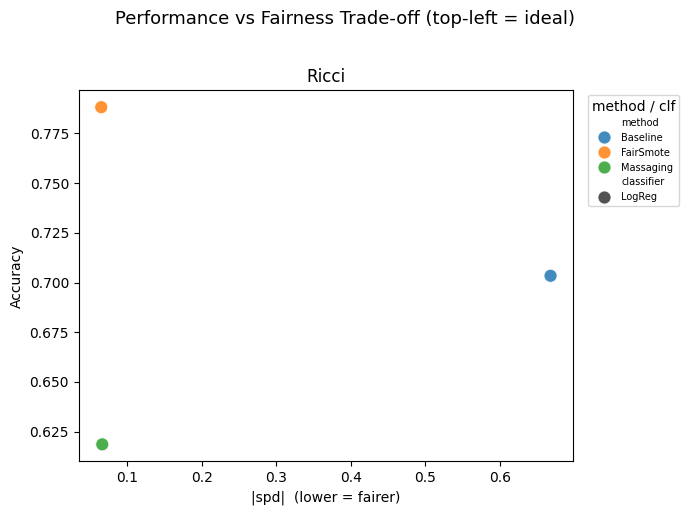

In [10]:
report.plot_tradeoff(fairness_metric="spd", performance_metric="accuracy");

Experiments can also be configured entirely from an XML file — see notebook 06.